# HVAC IoT Telemetry Analysis

## Data Analyst Intern Assignment

Analysis of HVAC/AC IoT telemetry data covering data cleaning,
time-series analysis, anomaly detection, energy usage, and
business recommendations.

## 1. Objective

The objective of this analysis is to clean and analyse HVAC IoT telemetry,
identify data-quality and operational anomalies, understand temperature
and power-usage patterns, estimate energy consumption, and provide
actionable business insights.

In [606]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading

The raw HVAC telemetry dataset is loaded into pandas for initial inspection
and data-quality checks.

In [607]:
df=pd.read_csv("/content/device_telemetry.csv")

## 3. Initial Data Inspection

The dataset was inspected to understand its structure, data types,
record count, missing values, and basic numerical distributions.

In [608]:
df.head()

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode
0,DVC-103,2026-06-06 03:15:00,25.74,26.0,25.74,0,49.0,OFF
1,DVC-102,2026-06-14 20:15:00,23.96,24.0,31.83,1,1420.6,COOL
2,DVC-101,2026-06-14 16:45:00,24.56,24.0,37.48,0,42.6,FAN
3,DVC-103,2026-06-01 03:30:00,26.04,26.0,25.88,0,52.1,OFF
4,DVC-102,2026-06-13 19:00:00,24.44,24.0,33.47,0,17.5,FAN


In [609]:
df.shape

(6470, 8)

In [610]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6470 entries, 0 to 6469
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   device_id         6470 non-null   object 
 1   timestamp         6470 non-null   object 
 2   room_temp_c       6470 non-null   float64
 3   setpoint_c        6470 non-null   float64
 4   ambient_temp_c    6470 non-null   float64
 5   compressor_state  6470 non-null   int64  
 6   power_watt        6470 non-null   float64
 7   mode              6470 non-null   object 
dtypes: float64(4), int64(1), object(3)
memory usage: 404.5+ KB


In [611]:
df.columns

Index(['device_id', 'timestamp', 'room_temp_c', 'setpoint_c', 'ambient_temp_c',
       'compressor_state', 'power_watt', 'mode'],
      dtype='object')

In [612]:
df['timestamp']=pd.to_datetime(df['timestamp'])

In [613]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6470 entries, 0 to 6469
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   device_id         6470 non-null   object        
 1   timestamp         6470 non-null   datetime64[ns]
 2   room_temp_c       6470 non-null   float64       
 3   setpoint_c        6470 non-null   float64       
 4   ambient_temp_c    6470 non-null   float64       
 5   compressor_state  6470 non-null   int64         
 6   power_watt        6470 non-null   float64       
 7   mode              6470 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 404.5+ KB


In [614]:
df['timestamp'].min()

Timestamp('2026-06-01 00:00:00')

In [615]:
df['timestamp'].max()

Timestamp('2026-06-14 23:45:00')

In [616]:
df['device_id'].nunique()

5

In [617]:
df['device_id'].unique()

array(['DVC-103', 'DVC-102', 'DVC-101', 'DVC-105', 'DVC-104'],
      dtype=object)

In [618]:
df.isnull().sum()

,0
device_id,0
timestamp,0
room_temp_c,0
setpoint_c,0
ambient_temp_c,0
compressor_state,0
power_watt,0
mode,0


In [619]:
df.duplicated().sum()

np.int64(32)

In [620]:
df[df.duplicated(keep=False)].sort_values(['device_id','timestamp']).head(20)

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode
200,DVC-101,2026-06-01 04:30:00,26.08,26.0,25.98,0,16.3,OFF
1276,DVC-101,2026-06-01 04:30:00,26.08,26.0,25.98,0,16.3,OFF
1612,DVC-101,2026-06-01 18:15:00,24.64,24.0,35.25,0,44.8,FAN
2387,DVC-101,2026-06-01 18:15:00,24.64,24.0,35.25,0,44.8,FAN
5972,DVC-101,2026-06-04 21:45:00,25.30,26.0,31.23,0,45.9,FAN
6267,DVC-101,2026-06-04 21:45:00,25.30,26.0,31.23,0,45.9,FAN
424,DVC-101,2026-06-10 00:00:00,26.40,26.0,26.34,0,49.4,OFF
4837,DVC-101,2026-06-10 00:00:00,26.40,26.0,26.34,0,49.4,OFF
26,DVC-101,2026-06-12 10:15:00,24.63,24.0,33.23,1,1327.6,COOL
1459,DVC-101,2026-06-12 10:15:00,24.63,24.0,33.23,1,1327.6,COOL


In [621]:
df['mode'].value_counts()

,count
mode,
OFF,2709
COOL,2280
FAN,1481


In [622]:
df['compressor_state'].value_counts()

,count
compressor_state,
0,4190
1,2280


In [623]:
df.describe()

,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt
count,6470,6470.000000,6470.000000,6470.000000,6470.000000,6470.000000
mean,2026-06-08 00:07:02.735703296,24.907362,25.002782,30.980975,0.352396,515.042875
min,2026-06-01 00:00:00,-99.000000,24.000000,23.050000,0.000000,8.000000
25%,2026-06-04 10:03:45,24.310000,24.000000,26.802500,0.000000,42.425000
50%,2026-06-08 00:45:00,24.795000,26.000000,30.980000,0.000000,52.800000
75%,2026-06-11 14:00:00,25.880000,26.000000,35.190000,1.000000,1285.975000
max,2026-06-14 23:45:00,85.000000,26.000000,38.740000,1.000000,5024.600000
std,NaN,5.240202,1.000073,4.289170,0.477753,655.594466


In [624]:
df['device_id'].value_counts().sort_index()

,count
device_id,
DVC-101,1330
DVC-102,1320
DVC-103,1177
DVC-104,1320
DVC-105,1323


In [625]:
df.groupby('device_id')['timestamp'].agg(['min','max'])

,min,max
device_id,,
DVC-101,2026-06-01,2026-06-14 23:45:00
DVC-102,2026-06-01,2026-06-14 23:45:00
DVC-103,2026-06-01,2026-06-14 23:45:00
DVC-104,2026-06-01,2026-06-14 23:45:00
DVC-105,2026-06-01,2026-06-14 23:45:00


## 4. Data Cleaning

The telemetry data contains duplicate records, invalid temperature values,
and irregular time intervals. These issues were identified and handled
before performing the time-series analysis.

In [626]:
df[df['room_temp_c'].isin([-99,85])]

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode
148,DVC-105,2026-06-05 16:45:00,-99.0,24.0,37.17,1,1279.6,COOL
222,DVC-102,2026-06-10 14:30:00,-99.0,24.0,36.49,0,45.7,FAN
446,DVC-101,2026-06-02 11:15:00,-99.0,24.0,33.74,1,1540.9,COOL
620,DVC-101,2026-06-06 08:00:00,-99.0,26.0,29.51,1,1244.0,COOL
1099,DVC-101,2026-06-05 03:30:00,-99.0,26.0,25.37,0,44.1,OFF
1201,DVC-101,2026-06-08 22:45:00,-99.0,26.0,28.73,0,60.3,OFF
1585,DVC-103,2026-06-06 05:30:00,85.0,26.0,27.55,0,46.6,OFF
1775,DVC-104,2026-06-10 23:45:00,85.0,26.0,27.08,0,59.3,OFF
2184,DVC-104,2026-06-11 02:30:00,85.0,26.0,25.56,0,50.5,OFF
2656,DVC-104,2026-06-03 09:30:00,85.0,24.0,31.39,1,1388.5,COOL


In [627]:
df["room_temp_c"].isin([-99, 85]).sum()

np.int64(17)

In [628]:
df["room_temp_c"].isin([-99, 85]).value_counts()

,count
room_temp_c,
False,6453
True,17


In [629]:
df.loc[df["room_temp_c"].isin([-99, 85]), "room_temp_c"].value_counts()

,count
room_temp_c,
-99.0,9
85.0,8


In [630]:
df.loc[df["room_temp_c"].isin([-99, 85]), "device_id"].value_counts()

,count
device_id,
DVC-101,7
DVC-104,4
DVC-103,3
DVC-102,2
DVC-105,1


In [631]:
df.loc[
    df["room_temp_c"].isin([-99, 85]),
    ["device_id", "timestamp", "room_temp_c"]
].sort_values(["device_id", "timestamp"])

,device_id,timestamp,room_temp_c
446,DVC-101,2026-06-02 11:15:00,-99.0
5775,DVC-101,2026-06-02 15:15:00,85.0
1099,DVC-101,2026-06-05 03:30:00,-99.0
5480,DVC-101,2026-06-06 04:00:00,85.0
620,DVC-101,2026-06-06 08:00:00,-99.0
1201,DVC-101,2026-06-08 22:45:00,-99.0
4434,DVC-101,2026-06-13 02:00:00,85.0
2815,DVC-102,2026-06-09 10:30:00,-99.0
222,DVC-102,2026-06-10 14:30:00,-99.0
1585,DVC-103,2026-06-06 05:30:00,85.0


In [632]:
df["power_watt"].describe()

,power_watt
count,6470.000000
mean,515.042875
std,655.594466
min,8.000000
25%,42.425000
50%,52.800000
75%,1285.975000
max,5024.600000


In [633]:
df[["device_id", "timestamp", "power_watt", "compressor_state", "mode"]].sort_values("power_watt", ascending=False).head(10)

,device_id,timestamp,power_watt,compressor_state,mode
287,DVC-101,2026-06-12 06:15:00,5024.6,0,OFF
192,DVC-101,2026-06-10 03:45:00,4976.9,0,OFF
374,DVC-101,2026-06-11 09:30:00,4857.3,1,COOL
4354,DVC-101,2026-06-01 03:30:00,4803.8,0,OFF
4792,DVC-101,2026-06-13 01:45:00,4735.9,0,OFF
607,DVC-101,2026-06-09 00:45:00,4704.5,0,OFF
2863,DVC-101,2026-06-02 23:30:00,4692.4,0,OFF
6208,DVC-101,2026-06-01 13:00:00,4273.5,1,COOL
2791,DVC-101,2026-06-14 05:30:00,4257.3,0,OFF
4627,DVC-101,2026-06-05 23:00:00,4214.5,0,OFF


In [634]:
df[df["power_watt"] > 2000]["device_id"].value_counts()

,count
device_id,
DVC-101,15


### 4.1 Handling Duplicate Records

Duplicate records were identified using the device and timestamp and then removed
to avoid counting the same telemetry reading more than once.

In [635]:
df.duplicated(subset=["device_id", "timestamp"]).sum()

np.int64(32)

In [636]:
df_clean=df.copy()

In [637]:
df_clean.head(10)

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode
0,DVC-103,2026-06-06 03:15:00,25.74,26.0,25.74,0,49.0,OFF
1,DVC-102,2026-06-14 20:15:00,23.96,24.0,31.83,1,1420.6,COOL
2,DVC-101,2026-06-14 16:45:00,24.56,24.0,37.48,0,42.6,FAN
3,DVC-103,2026-06-01 03:30:00,26.04,26.0,25.88,0,52.1,OFF
4,DVC-102,2026-06-13 19:00:00,24.44,24.0,33.47,0,17.5,FAN
5,DVC-102,2026-06-02 18:45:00,24.71,24.0,34.68,0,55.1,FAN
6,DVC-101,2026-06-01 13:30:00,24.73,24.0,36.26,0,41.0,FAN
7,DVC-105,2026-06-09 20:45:00,24.12,24.0,31.41,1,1360.9,COOL
8,DVC-102,2026-06-05 22:00:00,25.00,26.0,28.87,0,54.9,OFF
9,DVC-105,2026-06-12 03:00:00,25.58,26.0,24.74,0,37.4,OFF


In [638]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6470 entries, 0 to 6469
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   device_id         6470 non-null   object        
 1   timestamp         6470 non-null   datetime64[ns]
 2   room_temp_c       6470 non-null   float64       
 3   setpoint_c        6470 non-null   float64       
 4   ambient_temp_c    6470 non-null   float64       
 5   compressor_state  6470 non-null   int64         
 6   power_watt        6470 non-null   float64       
 7   mode              6470 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 404.5+ KB


In [639]:
df_clean.duplicated().sum()

np.int64(32)

In [640]:
df_clean.drop_duplicates(inplace=True)

In [641]:
df_clean.duplicated().sum()

np.int64(0)

In [642]:
df_clean.shape

(6438, 8)

### 4.2 Time-Series Gap Detection

The time difference between consecutive readings was checked to identify gaps in the expected 15-minute telemetry sequence.

In [643]:
df_clean = df_clean.sort_values(["device_id", "timestamp"])

df_clean["time_diff"] = (df_clean.groupby("device_id")["timestamp"].diff())

In [644]:
df_clean.head(10)

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode,time_diff
6248,DVC-101,2026-06-01 00:00:00,26.89,26.0,26.94,0,68.1,OFF,NaT
123,DVC-101,2026-06-01 00:15:00,26.89,26.0,25.86,0,37.7,OFF,0 days 00:15:00
3927,DVC-101,2026-06-01 00:30:00,26.97,26.0,26.69,0,43.9,OFF,0 days 00:15:00
3396,DVC-101,2026-06-01 00:45:00,26.93,26.0,26.58,0,50.6,OFF,0 days 00:15:00
5584,DVC-101,2026-06-01 01:00:00,26.71,26.0,24.63,0,48.5,OFF,0 days 00:15:00
762,DVC-101,2026-06-01 01:15:00,26.82,26.0,24.84,0,49.7,OFF,0 days 00:15:00
2872,DVC-101,2026-06-01 01:30:00,26.73,26.0,25.53,0,39.9,OFF,0 days 00:15:00
5706,DVC-101,2026-06-01 01:45:00,26.63,26.0,25.13,0,42.5,OFF,0 days 00:15:00
3551,DVC-101,2026-06-01 02:00:00,26.53,26.0,25.19,0,54.2,OFF,0 days 00:15:00
5945,DVC-101,2026-06-01 02:15:00,26.28,26.0,24.60,0,53.6,OFF,0 days 00:15:00


In [645]:
df_clean["time_diff"].value_counts()

,count
time_diff,
0 days 00:15:00,6297
0 days 00:30:00,132
0 days 00:45:00,3
1 days 12:15:00,1


In [646]:
df_clean[df_clean["time_diff"] > pd.Timedelta("15min")]["device_id"].value_counts().sort_index()

,count
device_id,
DVC-101,22
DVC-102,30
DVC-103,30
DVC-104,30
DVC-105,24


In [647]:
df_clean[df_clean["time_diff"] > pd.Timedelta("15min")][["device_id", "timestamp", "time_diff"]]

,device_id,timestamp,time_diff
214,DVC-101,2026-06-01 03:00:00,0 days 00:30:00
5253,DVC-101,2026-06-01 20:15:00,0 days 00:30:00
280,DVC-101,2026-06-01 20:45:00,0 days 00:30:00
1387,DVC-101,2026-06-02 08:15:00,0 days 00:30:00
4131,DVC-101,2026-06-03 21:15:00,0 days 00:30:00
...,...,...,...
4703,DVC-105,2026-06-12 00:15:00,0 days 00:30:00
4429,DVC-105,2026-06-12 04:45:00,0 days 00:30:00
1640,DVC-105,2026-06-12 12:15:00,0 days 00:30:00
336,DVC-105,2026-06-12 22:30:00,0 days 00:30:00


In [648]:
df_clean["offline_flag"] = df_clean["time_diff"] > pd.Timedelta("15min")

In [649]:
df_clean["offline_flag"].value_counts()

,count
offline_flag,
False,6302
True,136


### 4.3 Handling Invalid Temperature Values

The room-temperature data was checked for implausible readings. Values such as
-99°C and 85°C were identified as invalid sensor readings and treated as missing.
A later check also identified 0°C as an implausible room-temperature value.

In [650]:
df_clean["room_temp_c"] = df_clean["room_temp_c"].replace([-99, 85], np.nan)

In [651]:
df_clean.isnull().sum()

,0
device_id,0
timestamp,0
room_temp_c,17
setpoint_c,0
ambient_temp_c,0
compressor_state,0
power_watt,0
mode,0
time_diff,5
offline_flag,0


In [652]:
df_clean["room_temp_c"].value_counts().head(10)

,count
room_temp_c,
23.50,559
24.30,46
24.33,46
24.47,45
24.45,44
24.49,44
24.44,44
24.57,43
24.65,43


In [653]:
df_clean[df_clean["room_temp_c"]==23.50]["device_id"].value_counts()

,count
device_id,
DVC-104,559


In [654]:
df_clean[df_clean["device_id"] == "DVC-104"]["room_temp_c"].value_counts(normalize=True).head()

,proportion
room_temp_c,
23.50,0.427044
24.35,0.008403
24.18,0.006875
24.13,0.006112
24.33,0.006112


In [655]:
df_clean[df_clean["device_id"] == "DVC-104"]["room_temp_c"].nunique()

272

In [656]:
df_clean.head(10)

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode,time_diff,offline_flag
6248,DVC-101,2026-06-01 00:00:00,26.89,26.0,26.94,0,68.1,OFF,NaT,False
123,DVC-101,2026-06-01 00:15:00,26.89,26.0,25.86,0,37.7,OFF,0 days 00:15:00,False
3927,DVC-101,2026-06-01 00:30:00,26.97,26.0,26.69,0,43.9,OFF,0 days 00:15:00,False
3396,DVC-101,2026-06-01 00:45:00,26.93,26.0,26.58,0,50.6,OFF,0 days 00:15:00,False
5584,DVC-101,2026-06-01 01:00:00,26.71,26.0,24.63,0,48.5,OFF,0 days 00:15:00,False
762,DVC-101,2026-06-01 01:15:00,26.82,26.0,24.84,0,49.7,OFF,0 days 00:15:00,False
2872,DVC-101,2026-06-01 01:30:00,26.73,26.0,25.53,0,39.9,OFF,0 days 00:15:00,False
5706,DVC-101,2026-06-01 01:45:00,26.63,26.0,25.13,0,42.5,OFF,0 days 00:15:00,False
3551,DVC-101,2026-06-01 02:00:00,26.53,26.0,25.19,0,54.2,OFF,0 days 00:15:00,False
5945,DVC-101,2026-06-01 02:15:00,26.28,26.0,24.60,0,53.6,OFF,0 days 00:15:00,False


## 5. Feature Engineering

### 5.1 Temperature Deviation

Temperature deviation is calculated as the difference between room temperature and the configured setpoint.

In [657]:
df_clean["temp_deviation_c"] = df_clean["room_temp_c"] - df_clean["setpoint_c"]

In [658]:
df_clean.head(10)

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode,time_diff,offline_flag,temp_deviation_c
6248,DVC-101,2026-06-01 00:00:00,26.89,26.0,26.94,0,68.1,OFF,NaT,False,0.89
123,DVC-101,2026-06-01 00:15:00,26.89,26.0,25.86,0,37.7,OFF,0 days 00:15:00,False,0.89
3927,DVC-101,2026-06-01 00:30:00,26.97,26.0,26.69,0,43.9,OFF,0 days 00:15:00,False,0.97
3396,DVC-101,2026-06-01 00:45:00,26.93,26.0,26.58,0,50.6,OFF,0 days 00:15:00,False,0.93
5584,DVC-101,2026-06-01 01:00:00,26.71,26.0,24.63,0,48.5,OFF,0 days 00:15:00,False,0.71
762,DVC-101,2026-06-01 01:15:00,26.82,26.0,24.84,0,49.7,OFF,0 days 00:15:00,False,0.82
2872,DVC-101,2026-06-01 01:30:00,26.73,26.0,25.53,0,39.9,OFF,0 days 00:15:00,False,0.73
5706,DVC-101,2026-06-01 01:45:00,26.63,26.0,25.13,0,42.5,OFF,0 days 00:15:00,False,0.63
3551,DVC-101,2026-06-01 02:00:00,26.53,26.0,25.19,0,54.2,OFF,0 days 00:15:00,False,0.53
5945,DVC-101,2026-06-01 02:15:00,26.28,26.0,24.60,0,53.6,OFF,0 days 00:15:00,False,0.28


In [659]:
df_clean["temp_deviation_c"].describe()

,temp_deviation_c
count,6421.000000
mean,0.004052
std,1.173500
min,-26.000000
25%,-0.280000
50%,0.170000
75%,0.460000
max,2.450000


In [660]:
df_clean[df_clean["room_temp_c"] < 25][["device_id", "timestamp", "room_temp_c", "setpoint_c", "temp_deviation_c"]].sort_values("room_temp_c").head(20)

,device_id,timestamp,room_temp_c,setpoint_c,temp_deviation_c
3352,DVC-102,2026-06-11 18:00:00,0.0,24.0,-24.0
4898,DVC-102,2026-06-05 14:15:00,0.0,24.0,-24.0
3067,DVC-101,2026-06-14 15:45:00,0.0,24.0,-24.0
4117,DVC-104,2026-06-10 14:00:00,0.0,24.0,-24.0
202,DVC-101,2026-06-13 00:30:00,0.0,26.0,-26.0
2939,DVC-101,2026-06-12 08:45:00,0.0,26.0,-26.0
2973,DVC-101,2026-06-04 23:45:00,0.0,26.0,-26.0
5444,DVC-105,2026-06-06 21:00:00,0.0,26.0,-26.0
1649,DVC-104,2026-06-12 11:15:00,23.5,24.0,-0.5
6036,DVC-104,2026-06-09 04:45:00,23.5,26.0,-2.5


In [661]:
df_clean[df_clean["room_temp_c"] < 20][["device_id", "timestamp", "room_temp_c", "setpoint_c", "temp_deviation_c"]].sort_values("room_temp_c").head(20)

,device_id,timestamp,room_temp_c,setpoint_c,temp_deviation_c
2973,DVC-101,2026-06-04 23:45:00,0.0,26.0,-26.0
2939,DVC-101,2026-06-12 08:45:00,0.0,26.0,-26.0
202,DVC-101,2026-06-13 00:30:00,0.0,26.0,-26.0
3067,DVC-101,2026-06-14 15:45:00,0.0,24.0,-24.0
4898,DVC-102,2026-06-05 14:15:00,0.0,24.0,-24.0
3352,DVC-102,2026-06-11 18:00:00,0.0,24.0,-24.0
4117,DVC-104,2026-06-10 14:00:00,0.0,24.0,-24.0
5444,DVC-105,2026-06-06 21:00:00,0.0,26.0,-26.0


### 5.2 Additional Temperature Validation

A further check of unusually low room temperatures identified 0°C readings.
These were also treated as invalid and converted to missing values.

In [662]:
df_clean["room_temp_c"] = df_clean["room_temp_c"].replace([0, -99, 85], np.nan)

In [663]:
df_clean["temp_deviation_c"] = (df_clean["room_temp_c"] - df_clean["setpoint_c"])

In [664]:
df_clean.isnull().sum()

,0
device_id,0
timestamp,0
room_temp_c,25
setpoint_c,0
ambient_temp_c,0
compressor_state,0
power_watt,0
mode,0
time_diff,5
offline_flag,0


In [665]:
df_clean.head(10)

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode,time_diff,offline_flag,temp_deviation_c
6248,DVC-101,2026-06-01 00:00:00,26.89,26.0,26.94,0,68.1,OFF,NaT,False,0.89
123,DVC-101,2026-06-01 00:15:00,26.89,26.0,25.86,0,37.7,OFF,0 days 00:15:00,False,0.89
3927,DVC-101,2026-06-01 00:30:00,26.97,26.0,26.69,0,43.9,OFF,0 days 00:15:00,False,0.97
3396,DVC-101,2026-06-01 00:45:00,26.93,26.0,26.58,0,50.6,OFF,0 days 00:15:00,False,0.93
5584,DVC-101,2026-06-01 01:00:00,26.71,26.0,24.63,0,48.5,OFF,0 days 00:15:00,False,0.71
762,DVC-101,2026-06-01 01:15:00,26.82,26.0,24.84,0,49.7,OFF,0 days 00:15:00,False,0.82
2872,DVC-101,2026-06-01 01:30:00,26.73,26.0,25.53,0,39.9,OFF,0 days 00:15:00,False,0.73
5706,DVC-101,2026-06-01 01:45:00,26.63,26.0,25.13,0,42.5,OFF,0 days 00:15:00,False,0.63
3551,DVC-101,2026-06-01 02:00:00,26.53,26.0,25.19,0,54.2,OFF,0 days 00:15:00,False,0.53
5945,DVC-101,2026-06-01 02:15:00,26.28,26.0,24.60,0,53.6,OFF,0 days 00:15:00,False,0.28


### 5.3 Compressor Runtime

In [666]:
df_clean["compressor_hours"] = df_clean["compressor_state"] * 0.25

In [667]:
df_clean[["compressor_state", "compressor_hours"]]

,compressor_state,compressor_hours
6248,0,0.0
123,0,0.0
3927,0,0.0
3396,0,0.0
5584,0,0.0
...,...,...
4306,0,0.0
2417,0,0.0
3265,0,0.0
1826,0,0.0


In [668]:
df_clean[df_clean["compressor_state"]==1][["compressor_state", "compressor_hours"]]

,compressor_state,compressor_hours
4864,1,0.25
3443,1,0.25
110,1,0.25
615,1,0.25
5178,1,0.25
...,...,...
1972,1,0.25
2949,1,0.25
676,1,0.25
1959,1,0.25


### 5.4 Energy Estimation

Energy is estimated from power consumption using the approximately 15-minute sampling interval.

Energy (Wh) = Power (W) × 0.25 hours

In [669]:
df_clean["energy_wh"] = df_clean["power_watt"] * 0.25

In [670]:
df_clean[["power_watt", "energy_wh"]]

,power_watt,energy_wh
6248,68.1,17.025
123,37.7,9.425
3927,43.9,10.975
3396,50.6,12.650
5584,48.5,12.125
...,...,...
4306,46.9,11.725
2417,56.4,14.100
3265,50.4,12.600
1826,52.3,13.075


In [671]:
df_clean.head(10)

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode,time_diff,offline_flag,temp_deviation_c,compressor_hours,energy_wh
6248,DVC-101,2026-06-01 00:00:00,26.89,26.0,26.94,0,68.1,OFF,NaT,False,0.89,0.0,17.025
123,DVC-101,2026-06-01 00:15:00,26.89,26.0,25.86,0,37.7,OFF,0 days 00:15:00,False,0.89,0.0,9.425
3927,DVC-101,2026-06-01 00:30:00,26.97,26.0,26.69,0,43.9,OFF,0 days 00:15:00,False,0.97,0.0,10.975
3396,DVC-101,2026-06-01 00:45:00,26.93,26.0,26.58,0,50.6,OFF,0 days 00:15:00,False,0.93,0.0,12.650
5584,DVC-101,2026-06-01 01:00:00,26.71,26.0,24.63,0,48.5,OFF,0 days 00:15:00,False,0.71,0.0,12.125
762,DVC-101,2026-06-01 01:15:00,26.82,26.0,24.84,0,49.7,OFF,0 days 00:15:00,False,0.82,0.0,12.425
2872,DVC-101,2026-06-01 01:30:00,26.73,26.0,25.53,0,39.9,OFF,0 days 00:15:00,False,0.73,0.0,9.975
5706,DVC-101,2026-06-01 01:45:00,26.63,26.0,25.13,0,42.5,OFF,0 days 00:15:00,False,0.63,0.0,10.625
3551,DVC-101,2026-06-01 02:00:00,26.53,26.0,25.19,0,54.2,OFF,0 days 00:15:00,False,0.53,0.0,13.550
5945,DVC-101,2026-06-01 02:15:00,26.28,26.0,24.60,0,53.6,OFF,0 days 00:15:00,False,0.28,0.0,13.400


### 5.5 Date and Hour Features

In [672]:
df_clean["reading_date"] = df_clean["timestamp"].dt.date
df_clean["reading_hour"] = df_clean["timestamp"].dt.hour

In [673]:
df_clean["reading_date"] = pd.to_datetime(df_clean["reading_date"])

In [674]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6438 entries, 6248 to 5009
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   device_id         6438 non-null   object         
 1   timestamp         6438 non-null   datetime64[ns] 
 2   room_temp_c       6413 non-null   float64        
 3   setpoint_c        6438 non-null   float64        
 4   ambient_temp_c    6438 non-null   float64        
 5   compressor_state  6438 non-null   int64          
 6   power_watt        6438 non-null   float64        
 7   mode              6438 non-null   object         
 8   time_diff         6433 non-null   timedelta64[ns]
 9   offline_flag      6438 non-null   bool           
 10  temp_deviation_c  6413 non-null   float64        
 11  compressor_hours  6438 non-null   float64        
 12  energy_wh         6438 non-null   float64        
 13  reading_date      6438 non-null   datetime64[ns] 
 14  reading_ho

In [675]:
df_clean.shape

(6438, 15)

In [676]:
df_clean.head(10)

,device_id,timestamp,room_temp_c,setpoint_c,ambient_temp_c,compressor_state,power_watt,mode,time_diff,offline_flag,temp_deviation_c,compressor_hours,energy_wh,reading_date,reading_hour
6248,DVC-101,2026-06-01 00:00:00,26.89,26.0,26.94,0,68.1,OFF,NaT,False,0.89,0.0,17.025,2026-06-01,0
123,DVC-101,2026-06-01 00:15:00,26.89,26.0,25.86,0,37.7,OFF,0 days 00:15:00,False,0.89,0.0,9.425,2026-06-01,0
3927,DVC-101,2026-06-01 00:30:00,26.97,26.0,26.69,0,43.9,OFF,0 days 00:15:00,False,0.97,0.0,10.975,2026-06-01,0
3396,DVC-101,2026-06-01 00:45:00,26.93,26.0,26.58,0,50.6,OFF,0 days 00:15:00,False,0.93,0.0,12.650,2026-06-01,0
5584,DVC-101,2026-06-01 01:00:00,26.71,26.0,24.63,0,48.5,OFF,0 days 00:15:00,False,0.71,0.0,12.125,2026-06-01,1
762,DVC-101,2026-06-01 01:15:00,26.82,26.0,24.84,0,49.7,OFF,0 days 00:15:00,False,0.82,0.0,12.425,2026-06-01,1
2872,DVC-101,2026-06-01 01:30:00,26.73,26.0,25.53,0,39.9,OFF,0 days 00:15:00,False,0.73,0.0,9.975,2026-06-01,1
5706,DVC-101,2026-06-01 01:45:00,26.63,26.0,25.13,0,42.5,OFF,0 days 00:15:00,False,0.63,0.0,10.625,2026-06-01,1
3551,DVC-101,2026-06-01 02:00:00,26.53,26.0,25.19,0,54.2,OFF,0 days 00:15:00,False,0.53,0.0,13.550,2026-06-01,2
5945,DVC-101,2026-06-01 02:15:00,26.28,26.0,24.60,0,53.6,OFF,0 days 00:15:00,False,0.28,0.0,13.400,2026-06-01,2


In [677]:
df_clean.to_csv("cleaned_telemetry.csv", index=False)

## 6. SQL Analysis

SQL was used to create hourly, daily, device-level and anomaly summaries from the cleaned telemetry data.

In [678]:
hourly_summary = pd.read_csv("hourly_summary.csv")
daily_summary = pd.read_csv("daily_summary.csv")
device_summary = pd.read_csv("device_summary.csv")
offline_summary = pd.read_csv("offline_summary.csv")
power_anomalies = pd.read_csv("power_anomalies.csv")

In [679]:
hourly_summary.shape, daily_summary.shape, device_summary.shape, offline_summary.shape, power_anomalies.shape

((1644, 6), (70, 5), (5, 4), (5, 2), (15, 5))

### 6.1 Load and Prepare SQL Results

In [680]:
hourly_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1644 entries, 0 to 1643
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   device_id                 1644 non-null   object 
 1   reading_date              1644 non-null   object 
 2   reading_hour              1644 non-null   int64  
 3   avg_room_temp             1644 non-null   float64
 4   avg_power                 1644 non-null   float64
 5   compressor_runtime_hours  1644 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 77.2+ KB


In [681]:
hourly_summary["reading_date"] = pd.to_datetime(
    hourly_summary["reading_date"],
    format="%d-%m-%Y"
)

In [682]:
hourly_summary.dtypes

,0
device_id,object
reading_date,datetime64[ns]
reading_hour,int64
avg_room_temp,float64
avg_power,float64
compressor_runtime_hours,float64


## 7. Visualizations

### 7.1 Hourly Average Room Temperature

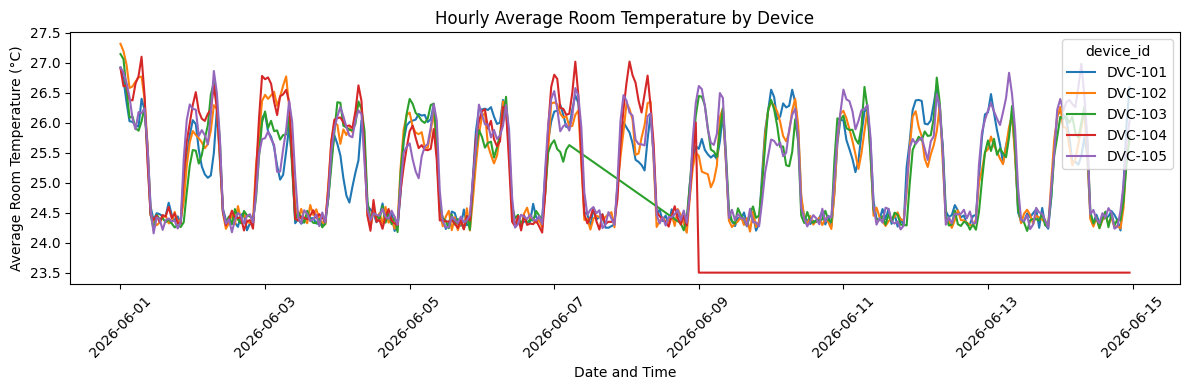

In [683]:
plot_time = (
    hourly_summary["reading_date"]
    + pd.to_timedelta(hourly_summary["reading_hour"], unit="h")
)

plt.figure(figsize=(12, 4))

sns.lineplot(
    x=plot_time,
    y=hourly_summary["avg_room_temp"],
    hue=hourly_summary["device_id"]
)

plt.title("Hourly Average Room Temperature by Device")
plt.xlabel("Date and Time")
plt.ylabel("Average Room Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.2 Hourly Average Power Usage

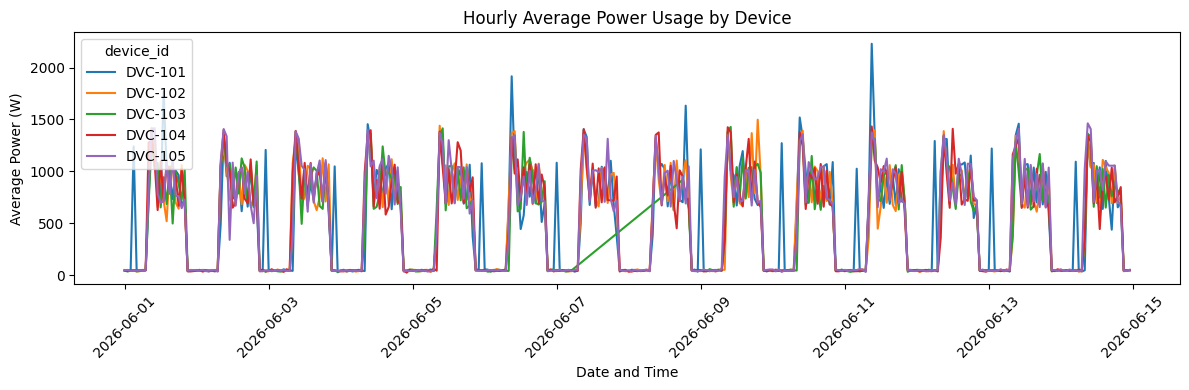

In [684]:
plt.figure(figsize=(12, 4))

sns.lineplot(
    x=plot_time,
    y=hourly_summary["avg_power"],
    hue=hourly_summary["device_id"]
)

plt.title("Hourly Average Power Usage by Device")
plt.xlabel("Date and Time")
plt.ylabel("Average Power (W)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.3 Estimated Energy Consumption by Device

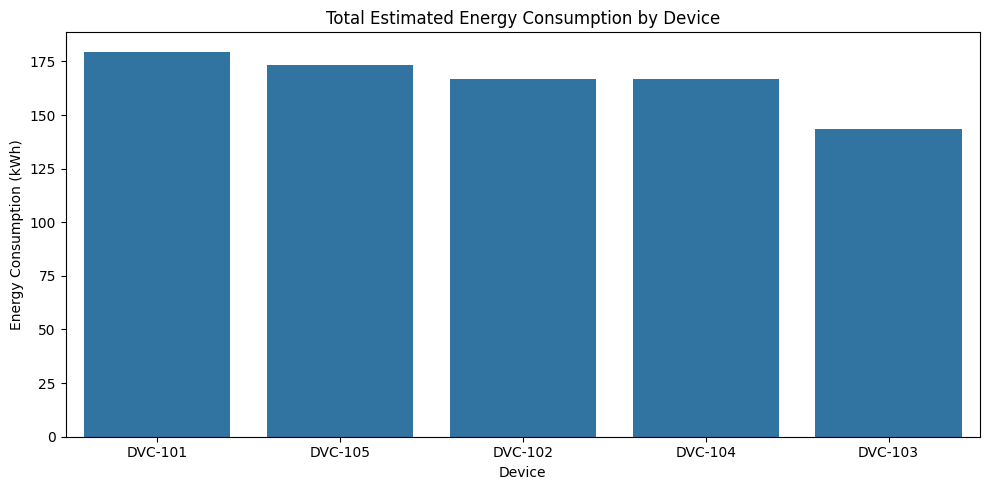

In [685]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=device_summary,
    x="device_id",
    y="total_energy_kwh"
)

plt.title("Total Estimated Energy Consumption by Device")
plt.xlabel("Device")
plt.ylabel("Energy Consumption (kWh)")
plt.tight_layout()
plt.show()

### 7.4 Setpoint Miss Rate by Device

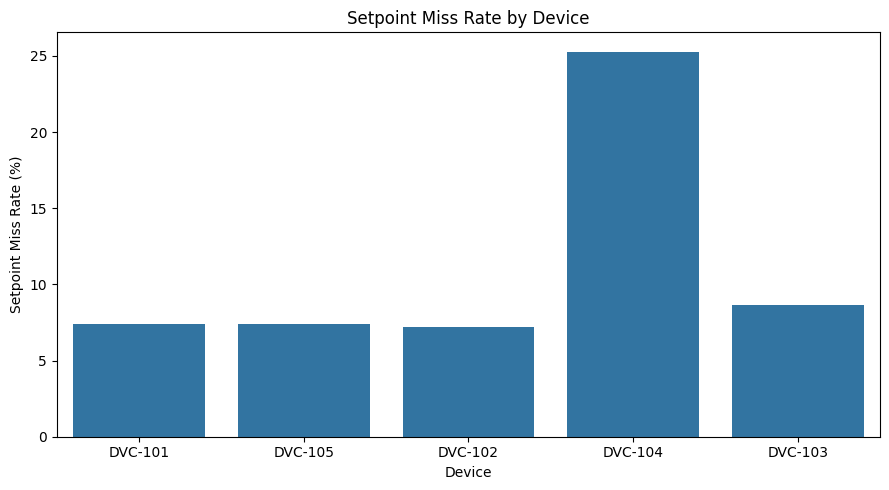

In [686]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=device_summary,
    x="device_id",
    y="setpoint_miss_percent"
)

plt.title("Setpoint Miss Rate by Device")
plt.xlabel("Device")
plt.ylabel("Setpoint Miss Rate (%)")
plt.tight_layout()
plt.show()

### 7.5 Detected Offline Gaps

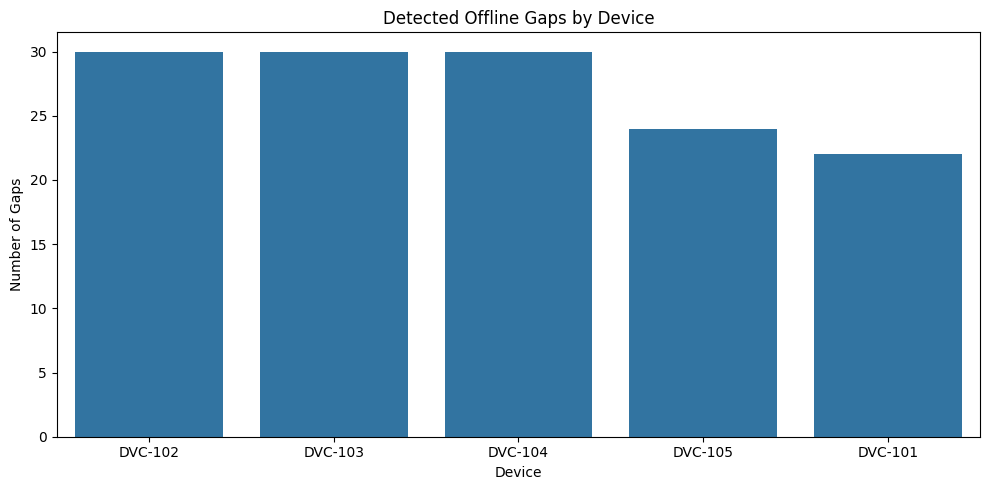

In [687]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=offline_summary,
    x="device_id",
    y="offline_gap_count"
)

plt.title("Detected Offline Gaps by Device")
plt.xlabel("Device")
plt.ylabel("Number of Gaps")
plt.tight_layout()
plt.show()

### 7.6 Average Power by Hour of Day

In [688]:
hourly_power_pattern = (
    hourly_summary
    .groupby("reading_hour", as_index=False)["avg_power"]
    .mean()
)

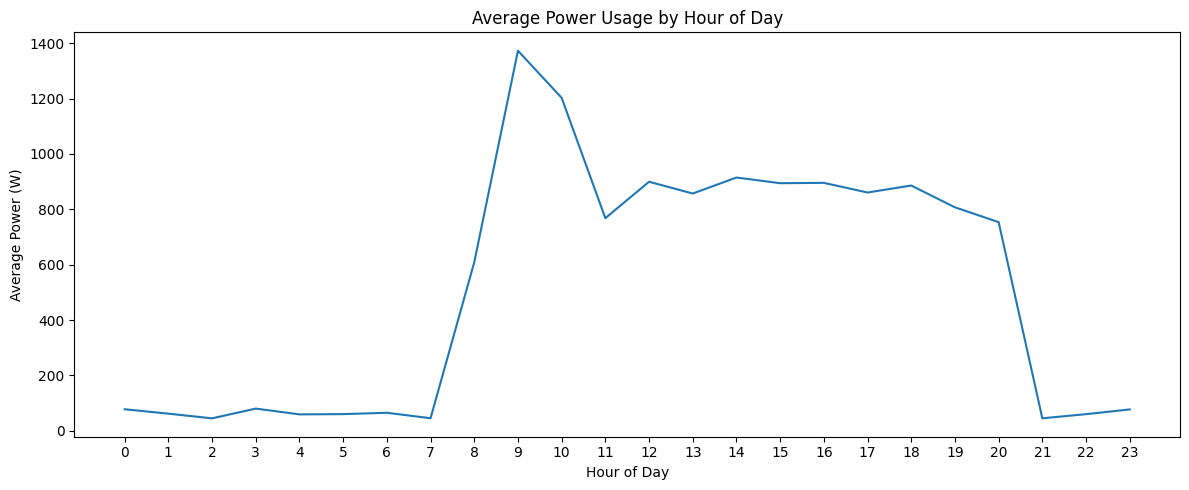

In [689]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_power_pattern,
    x="reading_hour",
    y="avg_power"
)

plt.title("Average Power Usage by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power (W)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

### 7.7 Daily Average Power Usage

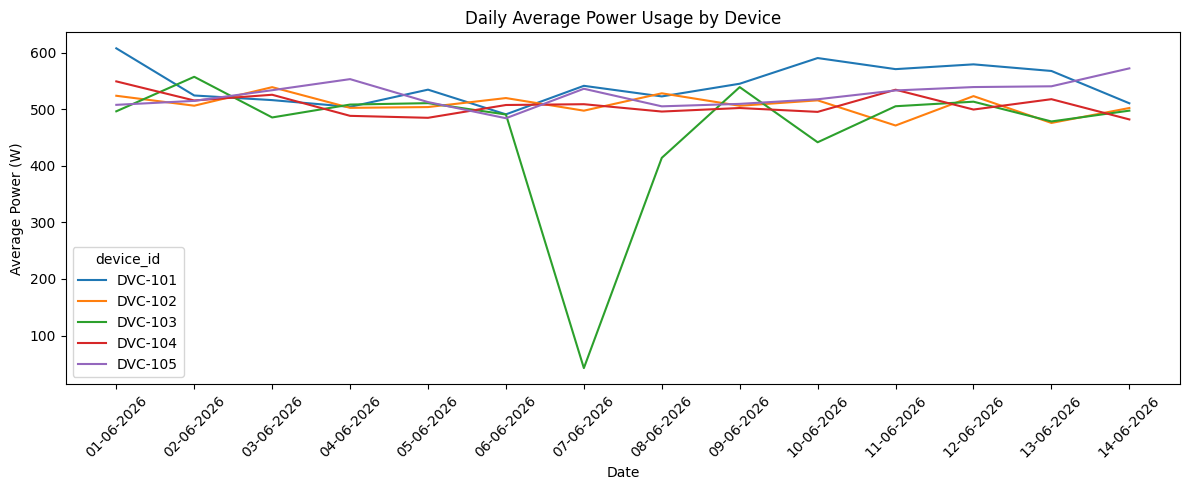

In [690]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=daily_summary,
    x="reading_date",
    y="avg_power",
    hue="device_id"
)

plt.title("Daily Average Power Usage by Device")
plt.xlabel("Date")
plt.ylabel("Average Power (W)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Key Findings

The analysis identified differences in energy consumption, temperature control,
telemetry reliability, and abnormal power behaviour across the five HVAC devices.

In [691]:
device_summary

,device_id,total_energy_kwh,setpoint_miss_count,setpoint_miss_percent
0,DVC-101,179.567025,98,7.413011
1,DVC-105,173.470575,98,7.424242
2,DVC-102,166.787350,95,7.235339
3,DVC-104,166.651175,332,25.285605
4,DVC-103,143.578600,101,8.632479


In [692]:
offline_summary

,device_id,offline_gap_count
0,DVC-102,30
1,DVC-103,30
2,DVC-104,30
3,DVC-105,24
4,DVC-101,22


### Main Observations

- DVC-101 has the highest estimated energy consumption.
- DVC-104 has a substantially higher setpoint miss rate than the other devices.
- DVC-104 shows suspicious repeated room-temperature readings around 23.5°C.
- DVC-101 has several high-power readings, including cases where the compressor is OFF.
- DVC-102, DVC-103 and DVC-104 have the highest number of detected telemetry gaps.

## 9. Business Recommendations

Based on the analysis, the following actions could help improve HVAC performance
and reduce unnecessary energy usage.

1. **Investigate DVC-104:** Its setpoint miss rate is much higher than the other
   devices, and its room-temperature readings show suspicious repeated values.
   The unit and temperature sensor should be checked.

2. **Investigate DVC-101 power behaviour:** DVC-101 has the highest estimated
   energy consumption and several high-power readings. The readings that occur
   while the compressor is OFF should be investigated for possible equipment
   or telemetry issues.

3. **Monitor devices with repeated telemetry gaps:** DVC-102, DVC-103 and
   DVC-104 have the highest number of detected gaps. Connectivity or telemetry
   reliability should be checked for these devices.

4. **Focus on high-usage periods:** Power usage is highest during the main
   daytime operating period, so energy-efficiency checks can be prioritised
   during these hours.

## 10. Assumptions and Limitations

- A temperature deviation greater than 1°C from the setpoint was used as the
  working definition of a setpoint miss.
- Power readings above 2000 W were treated as high-power spike candidates for
  anomaly investigation.
- Energy consumption was estimated assuming each telemetry reading represents
  approximately 15 minutes.
- Missing 15-minute intervals were treated as potential telemetry/offline gaps.
- Repeated room-temperature values were treated as a potential sensor issue
  when they showed unusually persistent behaviour.

## 11. 15-Minute Time-Series Validation

The cleaned data was aligned to a regular 15-minute interval and newly created missing intervals were flagged as gaps.

In [693]:
df_aligned = (
    df_clean
    .set_index("timestamp")
    .groupby("device_id")
    .resample("15min")
    .asfreq()
    .drop(columns="device_id")
    .reset_index()
)

In [694]:
df_aligned.shape

(6720, 15)

In [695]:
df_aligned["gap_flag"] = df_aligned["room_temp_c"].isnull() & df_aligned["setpoint_c"].isnull()

In [696]:
df_aligned["gap_flag"].value_counts()

,count
gap_flag,
False,6438
True,282


In [697]:
import plotly.express as px

fig = px.line(
    hourly_summary,
    x=plot_time,
    y="avg_room_temp",
    color="device_id",
    title="Hourly Average Room Temperature by Device"
)

fig.update_layout(
    xaxis_title="Date and Time",
    yaxis_title="Average Room Temperature (°C)"
)

fig.show()

## 12. Interactive HTML Report

In [698]:
import plotly.express as px
from plotly.io import to_html

# ---------- Charts ----------

# 1. Hourly room temperature
fig_temp = px.line(
    hourly_summary,
    x=plot_time,
    y="avg_room_temp",
    color="device_id",
    title="Hourly Average Room Temperature by Device"
)

fig_temp.update_layout(
    xaxis_title="Date and Time",
    yaxis_title="Average Room Temperature (°C)"
)

# 2. Hourly power
fig_power = px.line(
    hourly_summary,
    x=plot_time,
    y="avg_power",
    color="device_id",
    title="Hourly Average Power Usage by Device"
)

fig_power.update_layout(
    xaxis_title="Date and Time",
    yaxis_title="Average Power (W)"
)

# 3. Energy by device
fig_energy = px.bar(
    device_summary,
    x="device_id",
    y="total_energy_kwh",
    title="Estimated Energy Consumption by Device"
)

fig_energy.update_layout(
    xaxis_title="Device",
    yaxis_title="Energy Consumption (kWh)"
)

# 4. Setpoint miss rate
fig_setpoint = px.bar(
    device_summary,
    x="device_id",
    y="setpoint_miss_percent",
    title="Setpoint Miss Rate by Device"
)

fig_setpoint.update_layout(
    xaxis_title="Device",
    yaxis_title="Setpoint Miss Rate (%)"
)

# 5. Offline gaps
fig_offline = px.bar(
    offline_summary,
    x="device_id",
    y="offline_gap_count",
    title="Detected Offline Gaps by Device"
)

fig_offline.update_layout(
    xaxis_title="Device",
    yaxis_title="Number of Gaps"
)

# 6. Average power by hour
fig_hour = px.line(
    hourly_power_pattern,
    x="reading_hour",
    y="avg_power",
    title="Average Power Usage by Hour of Day"
)

fig_hour.update_layout(
    xaxis_title="Hour of Day",
    yaxis_title="Average Power (W)"
)


# ---------- Report ----------

report = f"""
<html>
<head>
    <title>HVAC IoT Telemetry Analysis</title>
    <meta charset="utf-8">
    <style>
        body {{
            font-family: Arial, sans-serif;
            max-width: 1100px;
            margin: 40px auto;
            padding: 0 20px;
            line-height: 1.6;
        }}
        h1, h2 {{
            color: #222;
        }}
        .summary {{
            background: #f4f4f4;
            padding: 18px;
            border-radius: 8px;
        }}
        li {{
            margin-bottom: 10px;
        }}
    </style>
</head>

<body>

<h1>HVAC IoT Telemetry Analysis</h1>

<p>
This analysis examines approximately two weeks of HVAC telemetry data
across five devices. The analysis covers data cleaning, time-series
summaries, anomaly detection, energy usage and operational insights.
</p>

<h2>Data Quality Summary</h2>

<div class="summary">
<ul>
    <li>32 duplicate rows were removed.</li>
    <li>25 implausible room-temperature readings were converted to missing values.</li>
    <li>The data was aligned to a regular 15-minute interval.</li>
    <li>282 missing 15-minute intervals were created during alignment and flagged as gaps.</li>
    <li>136 offline/gap events were detected from the original telemetry intervals.</li>
</ul>
</div>

<h2>Key Findings</h2>

<ul>
    <li>
        <b>DVC-101 had the highest estimated energy consumption</b>,
        at approximately 179.57 kWh.
    </li>

    <li>
        <b>DVC-104 had the highest setpoint miss rate</b>,
        at approximately 25.3%, while the other devices were around 7–9%.
    </li>

    <li>
        <b>DVC-104 showed suspicious flatline temperature behaviour</b>.
        Its room temperature remained around 23.5°C for an extended period,
        suggesting a possible stuck or faulty sensor.
    </li>

    <li>
        <b>DVC-101 recorded 15 high-power readings above 2000 W</b>.
        Of these, 11 occurred while the compressor was OFF, making them
        important candidates for further equipment or telemetry investigation.
    </li>

    <li>
        Power usage followed a clear daily cycle, with the main peak occurring
        around the morning operating period and lower usage overnight.
    </li>
</ul>


<h2>Business Recommendations</h2>

<ul>
    <li>
        Investigate DVC-104 first because its temperature-control performance
        is substantially worse than the other devices and its temperature
        signal shows suspicious flatline behaviour.
    </li>

    <li>
        Investigate the high-power readings from DVC-101, particularly cases
        where power remains very high while the compressor is reported OFF.
    </li>

    <li>
        Prioritise monitoring of devices with repeated telemetry gaps,
        especially DVC-102, DVC-103 and DVC-104.
    </li>

    <li>
        Use the observed daily power pattern to focus energy-efficiency
        checks and operational monitoring on higher-usage periods.
    </li>
</ul>

<h2>Assumptions and Limitations</h2>

<ul>
    <li>
        A room-temperature deviation greater than 1°C from the setpoint was
        used as the working definition of a setpoint miss.
    </li>

    <li>
        Power readings above 2000 W were treated as high-power spike candidates
        for investigation.
    </li>

    <li>
        Energy consumption was estimated assuming each telemetry reading
        represents approximately 15 minutes.
    </li>

    <li>
        Missing 15-minute intervals were treated as potential telemetry/offline gaps.
    </li>

    <li>
        Repeated room-temperature values were treated as potential sensor issues
        when they showed unusually persistent behaviour.
    </li>
</ul>

<h2>Interactive Visualisations</h2>

{to_html(fig_temp, full_html=False, include_plotlyjs=True)}

{to_html(fig_power, full_html=False)}

{to_html(fig_energy, full_html=False)}

{to_html(fig_setpoint, full_html=False)}

{to_html(fig_offline, full_html=False)}

{to_html(fig_hour, full_html=False)}

</body>
</html>
"""

with open("HVAC_Telemetry_Analysis_Report.html", "w", encoding="utf-8") as f:
    f.write(report)

print("Report created successfully.")

Report created successfully.
